In [15]:
import pandas as pd
import numpy as np

# Load ACC file
data = pd.read_csv(
    "../../data/raw/WESAD/S2/S2_E4_Data/ACC.csv",
    header=None
)

# Sampling frequency
fs = float(data.iloc[0, 0])

print("Sampling Frequency:", fs)

# Remove first row
acc_data = data.iloc[1:].astype(float)

# Extract axes
acc_x_raw = acc_data[0].values
acc_y_raw = acc_data[1].values
acc_z_raw = acc_data[2].values

print("Samples:", len(acc_x_raw))
print("X shape:", acc_x_raw.shape)
print("Y shape:", acc_y_raw.shape)
print("Z shape:", acc_z_raw.shape)

Sampling Frequency: 1495437325.0
Samples: 251971
X shape: (251971,)
Y shape: (251971,)
Z shape: (251971,)


In [16]:
import numpy as np

def moving_average(signal, window_size=5):
    return np.convolve(
        signal,
        np.ones(window_size)/window_size,
        mode='same'
    )

acc_x_filtered = moving_average(acc_x_raw, window_size=5)
acc_y_filtered = moving_average(acc_y_raw, window_size=5)
acc_z_filtered = moving_average(acc_z_raw, window_size=5)

In [17]:
import numpy as np

acc_mag_raw = np.sqrt(
    acc_x_raw**2 +
    acc_y_raw**2 +
    acc_z_raw**2
)

acc_mag_filtered = np.sqrt(
    acc_x_filtered**2 +
    acc_y_filtered**2 +
    acc_z_filtered**2
)

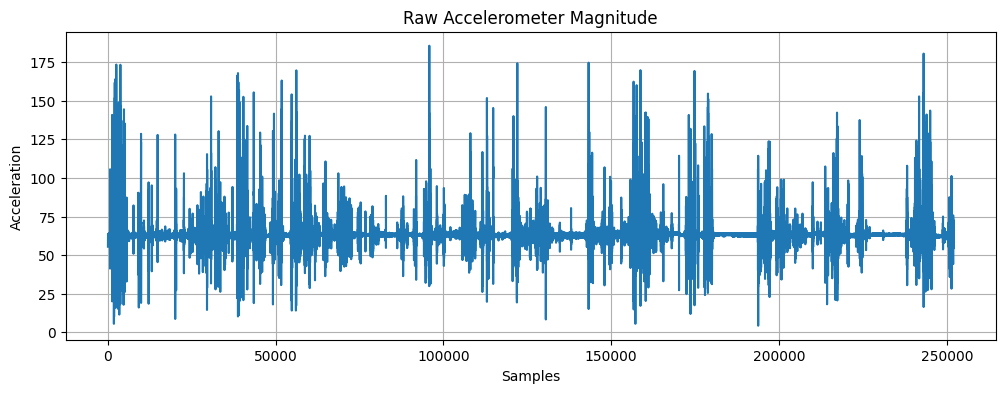

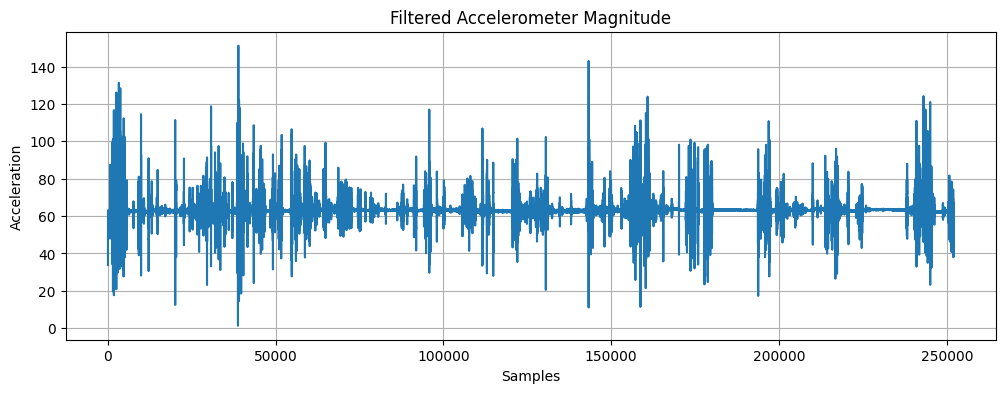

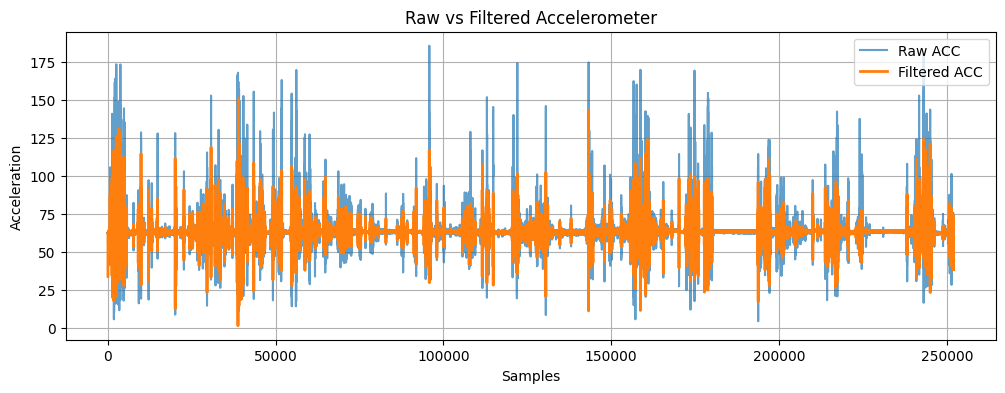

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(acc_mag_raw)

plt.title("Raw Accelerometer Magnitude")
plt.xlabel("Samples")
plt.ylabel("Acceleration")
plt.grid(True)

plt.show()
plt.figure(figsize=(12,4))

plt.plot(acc_mag_filtered)

plt.title("Filtered Accelerometer Magnitude")
plt.xlabel("Samples")
plt.ylabel("Acceleration")
plt.grid(True)

plt.show()
plt.figure(figsize=(12,4))

plt.plot(acc_mag_raw,
         label="Raw ACC",
         alpha=0.7)

plt.plot(acc_mag_filtered,
         label="Filtered ACC",
         linewidth=2)

plt.title("Raw vs Filtered Accelerometer")
plt.xlabel("Samples")
plt.ylabel("Acceleration")

plt.legend()
plt.grid(True)

plt.show()

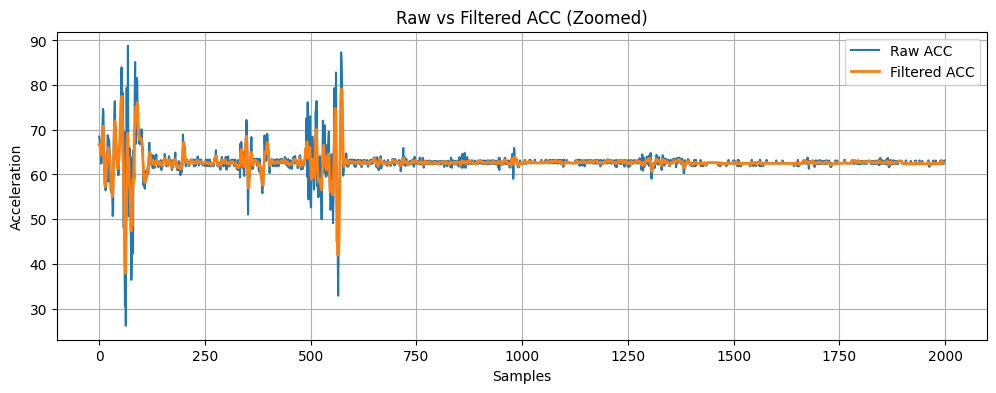

In [19]:
start = 5000
end = 7000

plt.figure(figsize=(12,4))

plt.plot(acc_mag_raw[start:end],
         label="Raw ACC")

plt.plot(acc_mag_filtered[start:end],
         label="Filtered ACC",
         linewidth=2)

plt.title("Raw vs Filtered ACC (Zoomed)")
plt.xlabel("Samples")
plt.ylabel("Acceleration")

plt.legend()
plt.grid(True)

plt.show()

In [20]:
import numpy as np
from scipy.stats import linregress

# -------------------------
# Noise
# -------------------------
def calculate_noise(signal):
    return np.std(np.diff(signal))

# -------------------------
# Spikes
# -------------------------
def count_spikes(signal, threshold=3):
    diff_signal = np.abs(np.diff(signal))
    spike_threshold = threshold * np.std(diff_signal)
    return np.sum(diff_signal > spike_threshold)

# -------------------------
# Drift
# -------------------------
def calculate_drift(signal):
    x = np.arange(len(signal))
    slope, _, _, _, _ = linregress(x, signal)
    return slope

# -------------------------
# Metrics
# -------------------------
def get_metrics(signal):
    return {
        "Samples": len(signal),
        "Mean": np.mean(signal),
        "Std": np.std(signal),
        "Min": np.min(signal),
        "Max": np.max(signal),
        "Range": np.max(signal) - np.min(signal),
        "Noise": calculate_noise(signal),
        "Spikes": count_spikes(signal),
        "Drift": calculate_drift(signal)
    }

raw_metrics = get_metrics(acc_mag_raw)
filtered_metrics = get_metrics(acc_mag_filtered)

print("========== ACC ==========")

for key in raw_metrics.keys():
    print(
        f"{key:<10} | Raw: {raw_metrics[key]:<12.6f} | "
        f"Filtered: {filtered_metrics[key]:<12.6f}"
    )

========== ACC ==========
Samples    | Raw: 251971.000000 | Filtered: 251971.000000
Mean       | Raw: 63.415415    | Filtered: 63.219640   
Std        | Raw: 5.269868     | Filtered: 3.562036    
Min        | Raw: 4.242641     | Filtered: 1.280625    
Max        | Raw: 185.698681   | Filtered: 151.192725  
Range      | Raw: 181.456040   | Filtered: 149.912100  
Noise      | Raw: 4.622805     | Filtered: 1.541165    
Spikes     | Raw: 5563.000000  | Filtered: 5938.000000 
Drift      | Raw: 0.000000     | Filtered: 0.000001    


In [21]:
print("\n========== CHANGE ==========")

for key in raw_metrics.keys():

    raw = raw_metrics[key]
    filt = filtered_metrics[key]

    if raw != 0:
        change = ((filt - raw) / raw) * 100
        print(f"{key:<10}: {change:.2f}%")


========== CHANGE ==========
Samples   : 0.00%
Mean      : -0.31%
Std       : -32.41%
Min       : -69.82%
Max       : -18.58%
Range     : -17.38%
Noise     : -66.66%
Spikes    : 6.74%
Drift     : 413.33%


| Metric |    Raw | Filtered | Conclusion                                                                      |
| ------ | -----: | -------: | ------------------------------------------------------------------------------- |
| Mean   |  63.42 |    63.22 | Preserved overall acceleration level (**0.31% change**)                         |
| Std    |   5.27 |     3.56 | Reduced by **32.4%**, indicating smoother signal                                |
| Min    |   4.24 |     1.28 | Lower minimum due to smoothing of local fluctuations                            |
| Max    | 185.70 |   151.19 | Reduced by **18.6%**, showing suppression of extreme motion artifacts           |
| Range  | 181.46 |   149.91 | Reduced by **17.4%**, indicating removal of excessive variations                |
| Noise  |   4.62 |     1.54 | Reduced by **66.7%**, demonstrating effective noise removal                     |
| Spikes |   5563 |     5938 | Slight increase (**6.7%**); likely due to threshold sensitivity after filtering |
| Drift  |     ~0 |       ~0 | No significant drift introduced; overall trend preserved                        |


| Observation                     | Result                                                                                         |
| ------------------------------- | ---------------------------------------------------------------------------------------------- |
| Noise Reduction                 | ✅ Significant improvement (**66.7% reduction**)                                                |
| Signal Smoothness               | ✅ Improved (**32.4% reduction in Std**)                                                        |
| Motion Information Preservation | ✅ Mean changed by only **0.31%**                                                               |
| Trend Preservation              | ✅ Drift remained negligible                                                                    |
| Filtering Effectiveness         | ✅ Successfully removed noise and motion artifacts while retaining meaningful movement patterns |
